Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')
Cột trong dữ liệu:
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

Kiểu dữ liệu:
customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
             age       balance
churn                         
0      37.408389  72745.296779
1      44.837997  91108.539337


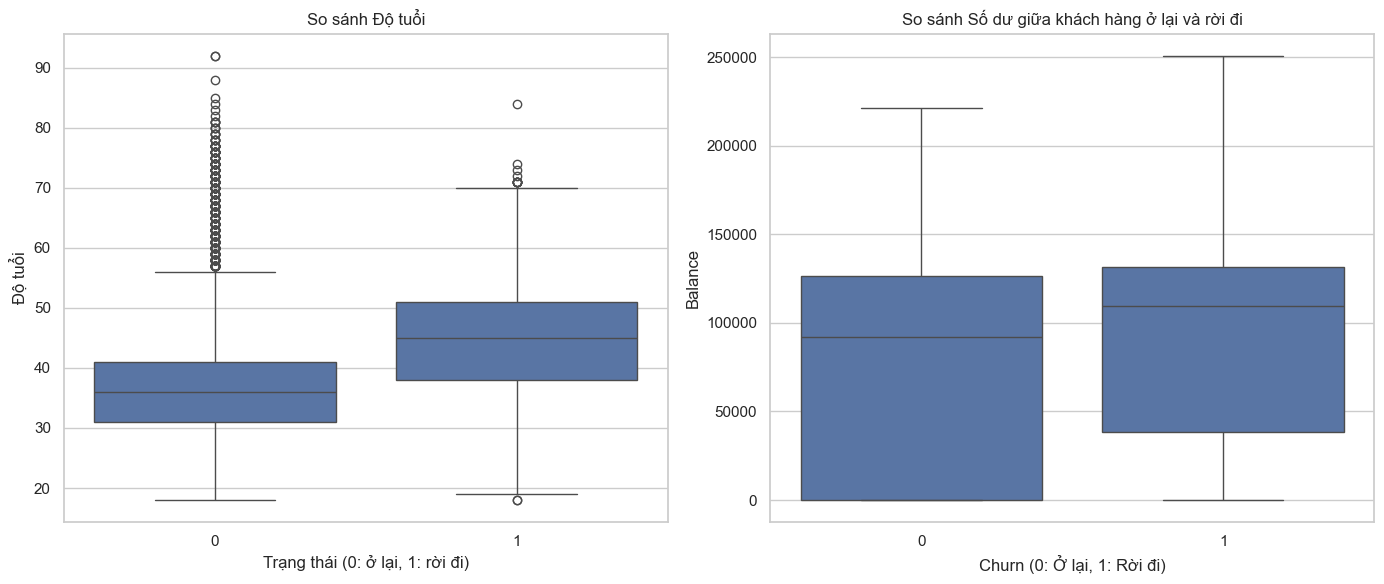

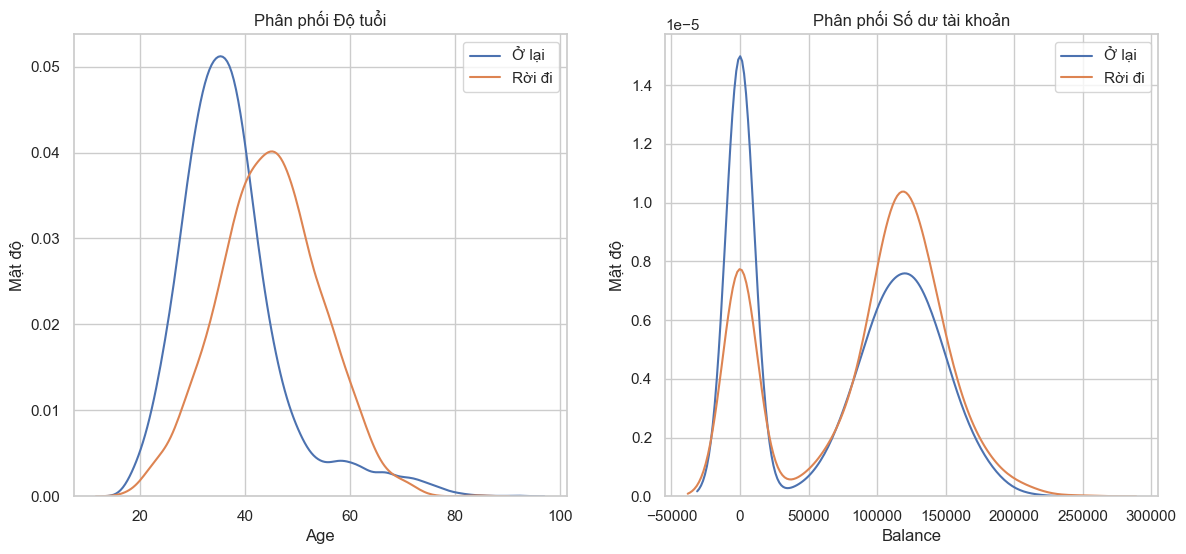

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

# Fix tên cột
df.columns = df.columns.str.strip()

# Kiểm tra nhanh
print(df.columns)
# Thống kê
print("Cột trong dữ liệu:")
print(df.columns)

print("\nKiểu dữ liệu:")
print(df.dtypes)

# Fix khoảng trắng
df.columns = df.columns.str.strip()

# Thử lại
comparison_stats = df.groupby('churn')[['age', 'balance']].mean()
print(comparison_stats)
# Boxplot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='churn', y='age', data=df)
plt.title('So sánh Độ tuổi')
plt.xlabel('Trạng thái (0: ở lại, 1: rời đi)')
plt.ylabel('Độ tuổi')

plt.subplot(1, 2, 2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('So sánh Số dư giữa khách hàng ở lại và rời đi')
plt.xlabel('Churn (0: Ở lại, 1: Rời đi)')
plt.ylabel('Balance')
plt.tight_layout()
plt.show()

# KDE
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(df[df['churn'] == 0]['age'], label='Ở lại')
sns.kdeplot(df[df['churn'] == 1]['age'], label='Rời đi')

plt.title('Phân phối Độ tuổi')
plt.xlabel('Age')
plt.ylabel('Mật độ')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(df[df['churn'] == 0]['balance'], label='Ở lại')
sns.kdeplot(df[df['churn'] == 1]['balance'], label='Rời đi')

plt.title('Phân phối Số dư tài khoản')
plt.xlabel('Balance')
plt.ylabel('Mật độ')
plt.legend()

plt.show()



=== GIÁ TRỊ TRUNG BÌNH ===
             age       balance
churn                         
0      37.408389  72745.296779
1      44.837997  91108.539337

=== PHƯƠNG SAI ===
              age       balance
churn                          
0      102.522974  3.949876e+09
1       95.288084  3.405982e+09


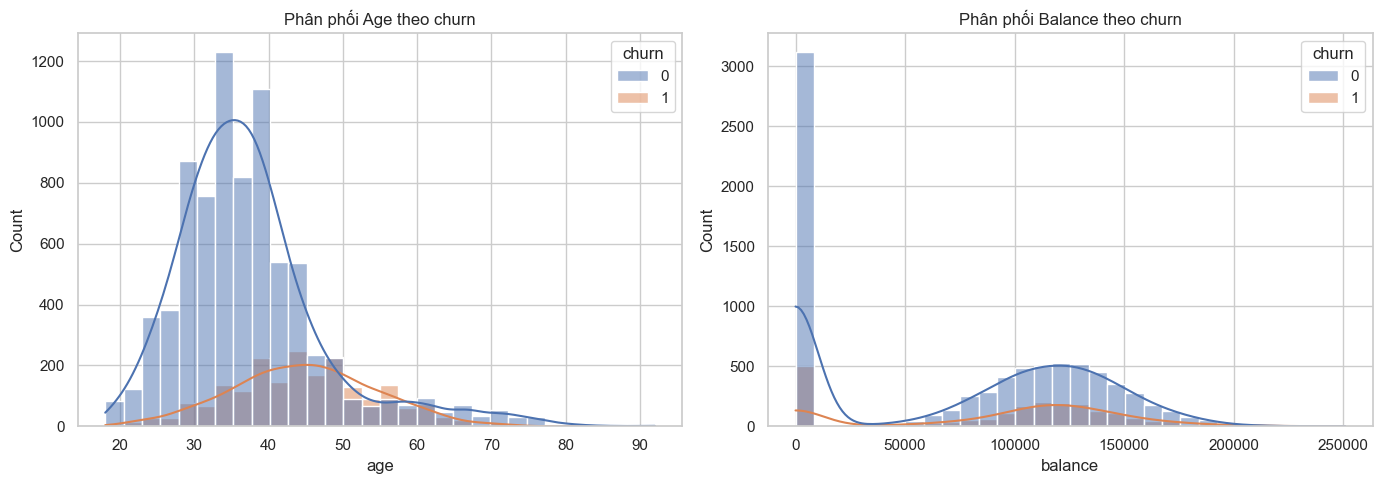

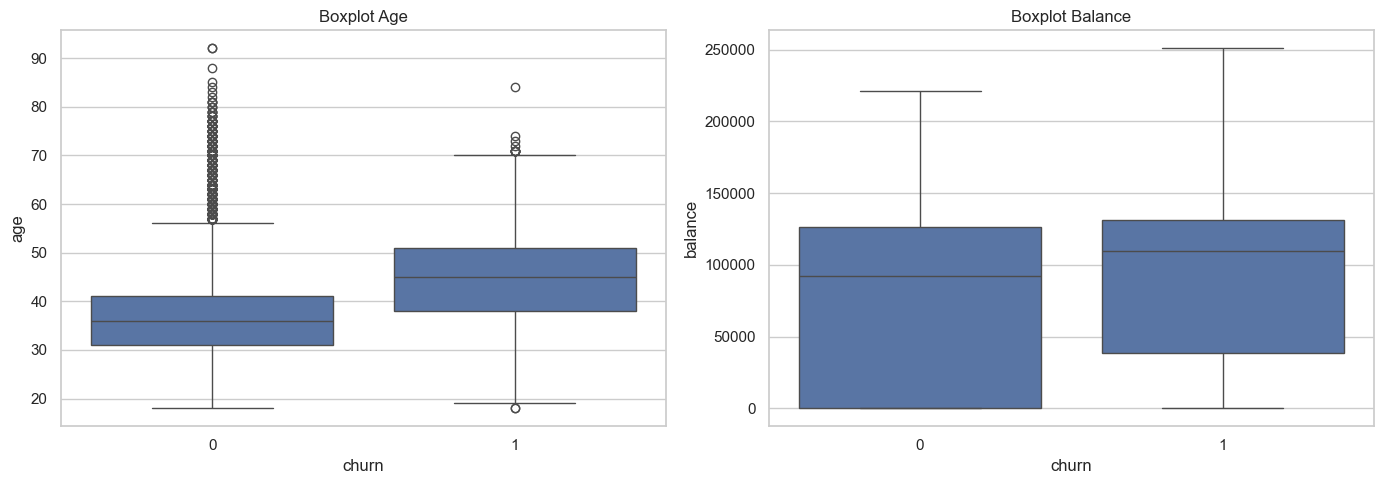

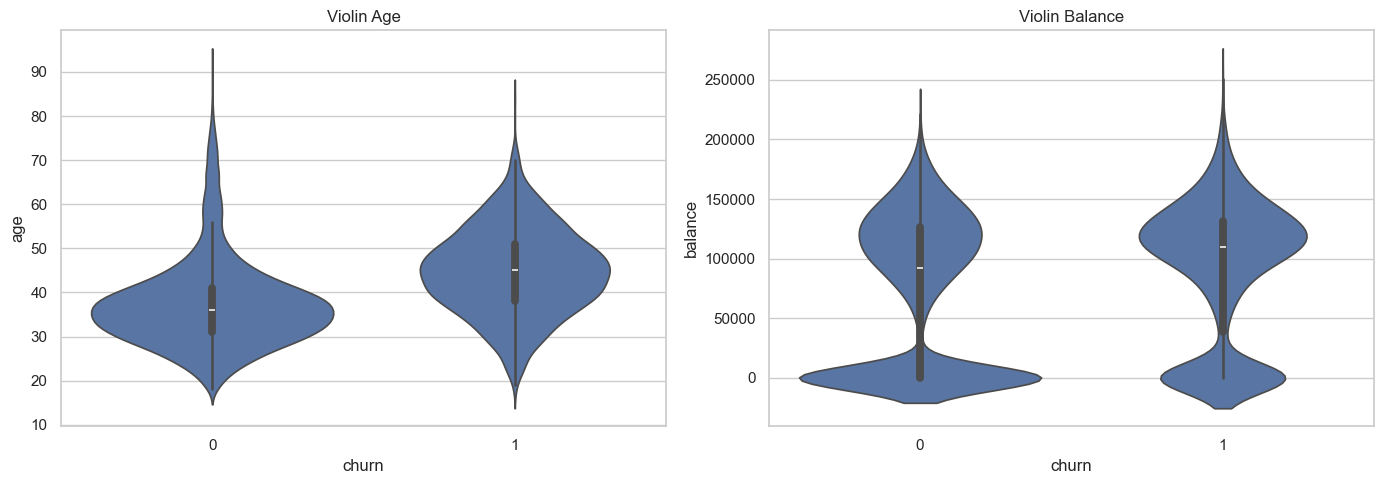

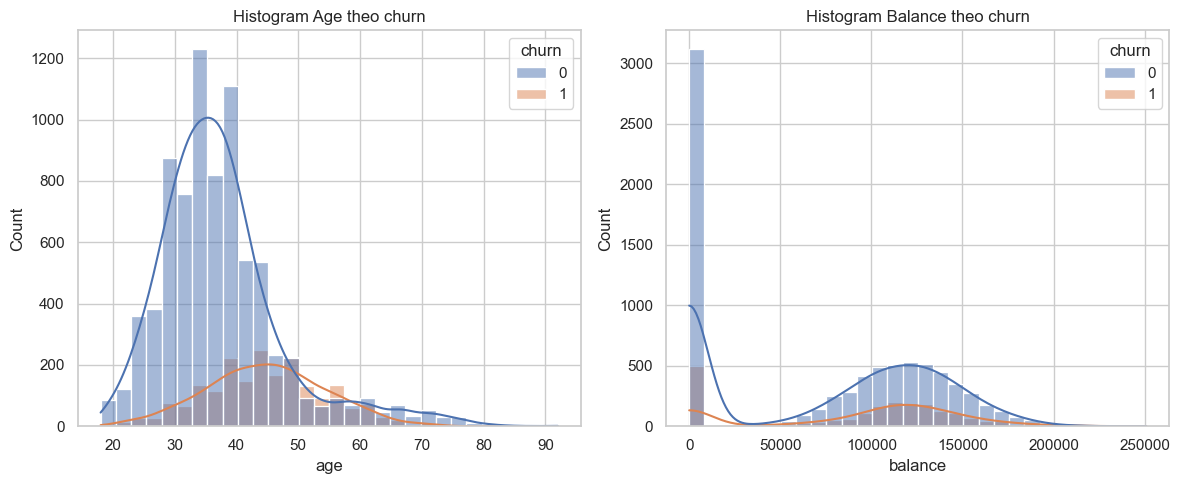


=== PHÂN TÍCH NGUYÊN NHÂN CHURN ===

Biến: credit_score
Ở lại (0): 651.85
Rời đi (1): 645.35
→ Giá trị THẤP hơn ở nhóm rời bỏ → có thể gây churn

Biến: age
Ở lại (0): 37.41
Rời đi (1): 44.84
→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn

Biến: balance
Ở lại (0): 72745.30
Rời đi (1): 91108.54
→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn

=== PHÂN TÍCH DỰA TRÊN NHÓM Ở LẠI (churn = 0) ===

--- GIÁ TRỊ CHUẨN (KHÔNG RỜI BỎ) ---
credit_score      651.853196
age                37.408389
balance         72745.296779
dtype: float64

--- SO SÁNH VỚI NHÓM RỜI BỎ ---

Biến: credit_score
Chuẩn (0): 651.85
Rời bỏ (1): 645.35
Chênh lệch: -6.50
→ Nhóm rời bỏ THẤP hơn chuẩn → đây có thể là yếu tố gây churn

Biến: age
Chuẩn (0): 37.41
Rời bỏ (1): 44.84
Chênh lệch: 7.43
→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn

Biến: balance
Chuẩn (0): 72745.30
Rời bỏ (1): 91108.54
Chênh lệch: 18363.24
→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn


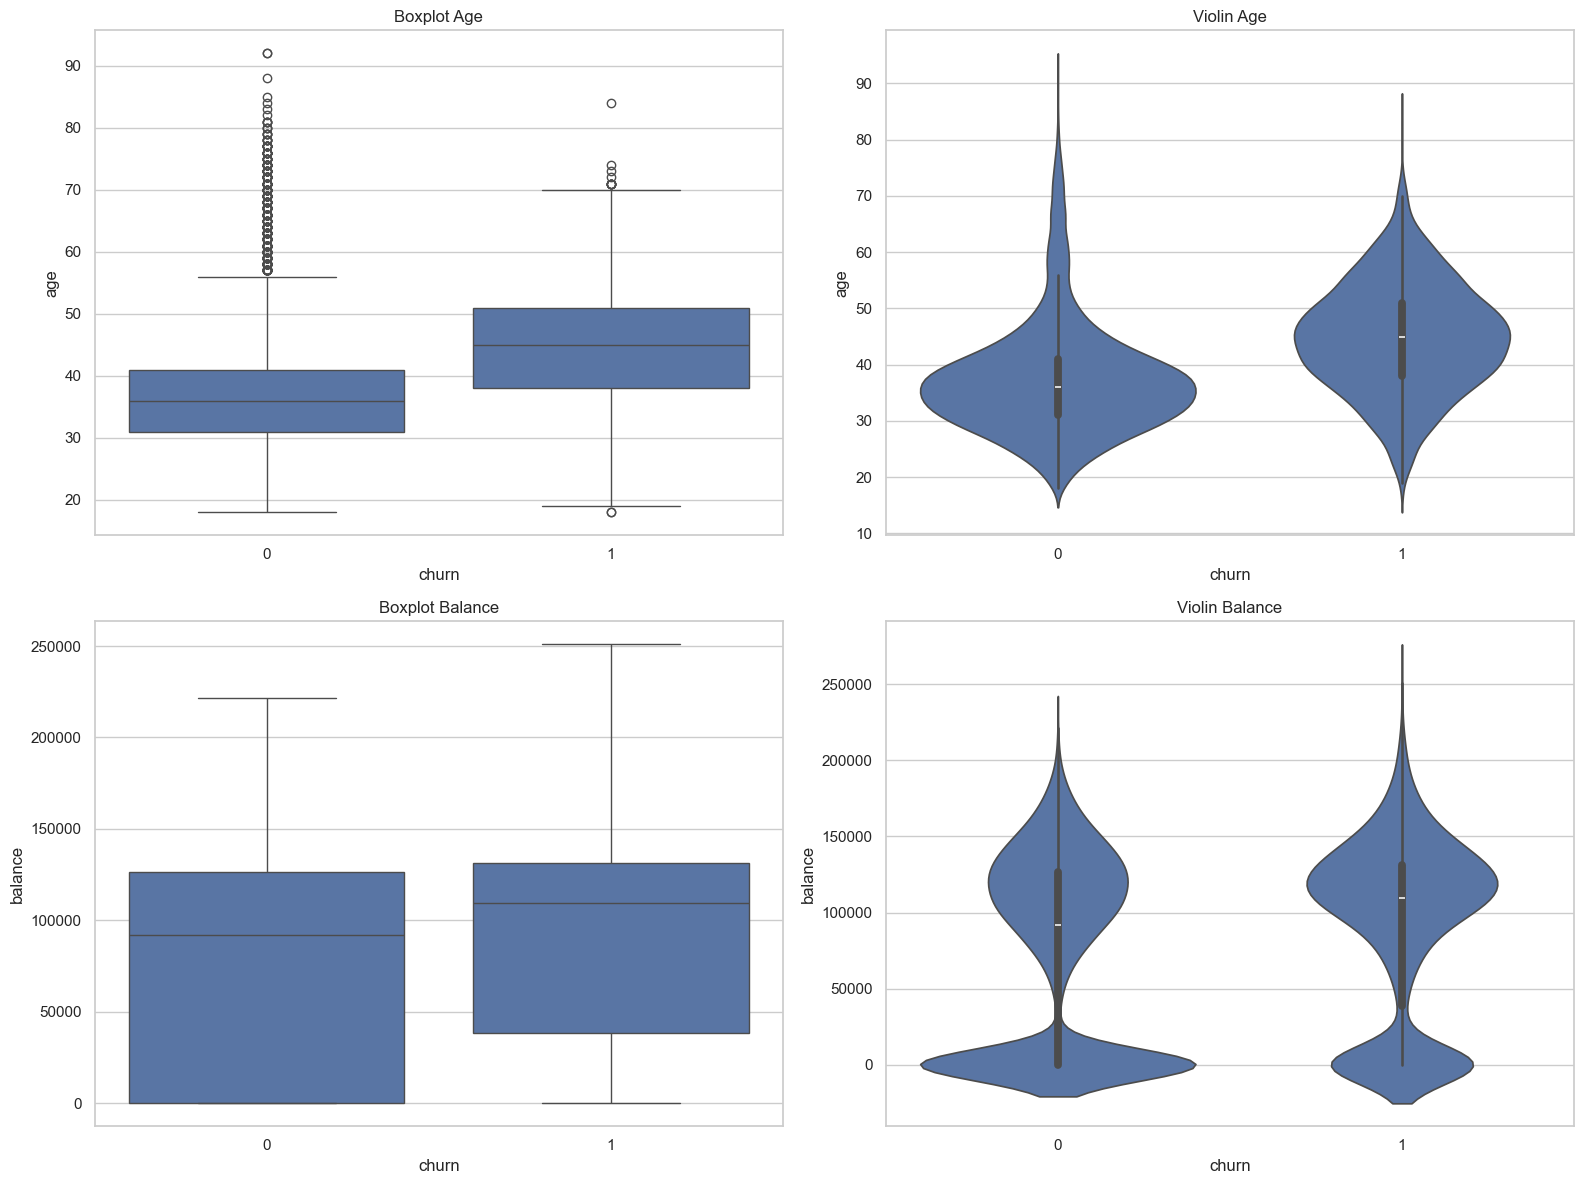

=== ẢNH HƯỞNG (%) ===
balance: 25.24%
age: 19.86%
credit_score: 1.00%

→ Biến ảnh hưởng mạnh nhất: balance


In [13]:
import pandas as pd                     
import seaborn as sns
import matplotlib.pyplot as plt                                 #pandas (pd) → xử lý dữ liệu dạng bảng (DataFrame)
                                                                #seaborn (sns) → vẽ biểu đồ thống kê đẹp, dễ dùng
                                                                # matplotlib.pyplot (plt) → thư viện nền để vẽ biểu đồ

# ==============================
# 1. Đọc dữ liệu
# ==============================
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')                                  #Đọc file CSV vào DataFrame df
                                                                                            # Mỗi dòng → 1 khách hàng
                                                                                            # Mỗi cột → thông tin (age, balance, churn,...)

# ==============================
# 2. So sánh giá trị trung bình
# ==============================
print("=== GIÁ TRỊ TRUNG BÌNH ===")
mean_values = df.groupby('churn')[['age', 'balance']].mean()
print(mean_values)                                                          
                                                                                            # groupby('churn') → chia dữ liệu thành 2 nhóm:
                                                                                            # churn = 0 → khách ở lại
                                                                                            # churn = 1 → khách rời đi
                                                                                            # [['age', 'balance']] → chỉ lấy 2 cột cần phân tích
                                                                                            # .mean() → tính trung bình

# ==============================
# 3. So sánh phương sai
# ==============================
print("\n=== PHƯƠNG SAI ===")
var_values = df.groupby('churn')[['age', 'balance']].var()
print(var_values)
                                                                                            # .var() → phương sai (mức độ phân tán)
                                                                                            # Ý nghĩa:

                                                                                            # Giá trị lớn → dữ liệu phân tán mạnh
                                                                                            # Giá trị nhỏ → dữ liệu tập trung
                                                                                            # Age churn=1 có var lớn → độ tuổi khách rời đi rất đa dạng
# Nếu dataset dùng 'Exited' thì đổi tên
if 'Exited' in df.columns:
    df.rename(columns={'Exited': 'churn'}, inplace=True)
                                                                                            # Vì dataset có thể dùng:

                                                                                            # Exited (chuẩn Kaggle)
                                                                                            # hoặc churn

                                                                                            # Nếu có Exited → đổi thành churn cho đồng nhất

# ==============================
# Histogram (so sánh phân phối tổng quan)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Phân phối Age theo churn')
                                                                                            # x='age' → vẽ theo tuổi
                                                                                            # hue='churn' → tách màu theo churn (0 và 1)
                                                                                            # bins=30 → chia 30 khoảng
                                                                                            # kde=True → thêm đường mật độ

                                                                                        #GT
                                                                                            # Xem phân phối tuổi giữa 2 nhóm
                                                                                            # Nhìn được:
                                                                                            # lệch trái/phải
                                                                                            # tập trung ở đâu

# Balance
plt.subplot(1,2,2)                                                                          #Chia khung vẽ:
                                                                                            # 1 hàng, 2 cột
                                                                                            # biểu đồ thứ 1
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Phân phối Balance theo churn')

plt.tight_layout()                                                                           #sửa căn chỉnh kcach cho cân đối
plt.show()

# ==============================
# Boxplot (so sánh median + outlier)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.boxplot(x='churn', y='age', data=df)                
plt.title('Boxplot Age')
                                                                                                                            # Hiển thị:

                                                                                                                            # Median (đường giữa)
                                                                                                                            # Q1, Q3 (hộp)
                                                                                                                            # Outlier (điểm lẻ)

                                                                                                                            #  Ý nghĩa:

                                                                                                                            # So sánh nhanh:
                                                                                                                            # tuổi trung vị
                                                                                                                            # độ phân tán
                                                                                                                            # ngoại lệ

                                                                                                                            #  Ví dụ:

                                                                                                                            # churn=1 có median cao → người lớn tuổi dễ rời đi

# Balance
plt.subplot(1,2,2)
sns.boxplot(x='churn', y='balance', data=df)
plt.title('Boxplot Balance')

plt.tight_layout()
plt.show()

# ==============================
#  Violin plot (so sánh mật độ phân phối)
# ==============================
plt.figure(figsize=(14,5))

# Age
plt.subplot(1,2,1)
sns.violinplot(x='churn', y='age', data=df)
plt.title('Violin Age')

# Balance
plt.subplot(1,2,2)
sns.violinplot(x='churn', y='balance', data=df)
plt.title('Violin Balance')

plt.tight_layout()
plt.show()
# ==============================
# 4. Histogram (theo churn)
# ==============================
plt.figure(figsize=(12,5))

# Age
plt.subplot(1,2,1)
sns.histplot(data=df, x='age', hue='churn', bins=30, kde=True)
plt.title('Histogram Age theo churn')

# Balance
plt.subplot(1,2,2)
sns.histplot(data=df, x='balance', hue='churn', bins=30, kde=True)
plt.title('Histogram Balance theo churn')

plt.tight_layout()
plt.show()

# ==============================
# 5. Boxplot + Violin (4 biểu đồ)
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# AGE
sns.boxplot(data=df, x='churn', y='age', ax=axes[0,0])
axes[0,0].set_title('Boxplot Age')

sns.violinplot(data=df, x='churn', y='age', ax=axes[0,1])
axes[0,1].set_title('Violin Age')

# BALANCE
sns.boxplot(data=df, x='churn', y='balance', ax=axes[1,0])
axes[1,0].set_title('Boxplot Balance')

sns.violinplot(data=df, x='churn', y='balance', ax=axes[1,1])
axes[1,1].set_title('Violin Balance')
# ==============================
#6 Phân tích nguyên nhân churn
# ==============================
print("\n=== PHÂN TÍCH NGUYÊN NHÂN CHURN ===")

features = ['credit_score','age','balance']

for col in features:
    mean_0 = df[df['churn'] == 0][col].mean()
    mean_1 = df[df['churn'] == 1][col].mean()
    
    print(f"\nBiến: {col}")
    print(f"Ở lại (0): {mean_0:.2f}")
    print(f"Rời đi (1): {mean_1:.2f}")
    
    if mean_1 > mean_0:
        print("→ Giá trị CAO hơn ở nhóm rời bỏ → có thể gây churn")
    else:
        print("→ Giá trị THẤP hơn ở nhóm rời bỏ → có thể gây churn")
        
    
        # ==============================
#7 PHÂN TÍCH DỰA TRÊN CHURN = 0 (BASELINE)
# ==============================
print("\n=== PHÂN TÍCH DỰA TRÊN NHÓM Ở LẠI (churn = 0) ===")

features = ['credit_score','age','balance']

# Trung bình nhóm chuẩn (churn = 0)
baseline = df[df['churn'] == 0][features].mean()

print("\n--- GIÁ TRỊ CHUẨN (KHÔNG RỜI BỎ) ---")
print(baseline)

# So sánh với churn = 1
print("\n--- SO SÁNH VỚI NHÓM RỜI BỎ ---")

for col in features:
    base = baseline[col]
    churn1 = df[df['churn'] == 1][col].mean()
    
    diff = churn1 - base
    
    print(f"\nBiến: {col}")
    print(f"Chuẩn (0): {base:.2f}")
    print(f"Rời bỏ (1): {churn1:.2f}")
    print(f"Chênh lệch: {diff:.2f}")
    
    # Phân tích theo hướng lệch
    if diff > 0:
        print("→ Nhóm rời bỏ CAO hơn chuẩn → đây có thể là yếu tố gây churn")
    else:
        print("→ Nhóm rời bỏ THẤP hơn chuẩn → đây có thể là yếu tố gây churn")

plt.tight_layout()
plt.show()
impact_percent = {}

for col in features:
    mean_0 = df[df['churn'] == 0][col].mean()
    mean_1 = df[df['churn'] == 1][col].mean()
    
    percent = abs((mean_1 - mean_0) / mean_0)
    impact_percent[col] = percent

sorted_impact = sorted(impact_percent.items(), key=lambda x: x[1], reverse=True)

print("=== ẢNH HƯỞNG (%) ===")
for var, val in sorted_impact:
    print(f"{var}: {val*100:.2f}%")

print("\n→ Biến ảnh hưởng mạnh nhất:", sorted_impact[0][0])

In [14]:
# NHẬN XÉT TRỰC QUAN HÓA SO SÁNH (CHURN VS NON-CHURN)
# Ý tưởng:

# Sử dụng kết hợp Boxplot và Violin Plot để so sánh sự khác biệt giữa hai nhóm khách hàng:

# Nhóm ở lại (churn = 0)
# Nhóm rời đi (churn = 1)
# Các biến được phân tích:

# age
# balance
# Mục đích:

# Xác định sự khác biệt về hành vi giữa 2 nhóm
# Tìm ra yếu tố ảnh hưởng đến việc rời bỏ dịch vụ
# Phương pháp trực quan hóa
# Boxplot
# So sánh:

# Trung vị (median)

# Độ phân tán

# Outliers

# Giúp thấy rõ sự khác biệt tổng quan

# Violin Plot

# Hiển thị:

# Phân phối dữ liệu (density)
# Hình dạng phân bố
# Giúp hiểu sâu hơn về cấu trúc dữ liệu
# Kết quả phân tích:

# Age (Độ tuổi)
# Nhóm churn = 1 (rời đi):

# Có xu hướng lớn tuổi hơn
# Median cao hơn rõ rệt

# Nhóm churn = 0 (ở lại):
# Tập trung ở nhóm tuổi trẻ hơn
# Violin plot cho thấy:

# Phân phối của nhóm rời đi lệch về phía tuổi cao
# Kết luận:

# Khách hàng lớn tuổi có xu hướng rời bỏ dịch vụ cao hơn
# Balance (Số dư tài khoản)
# Nhóm churn = 1:

# Có xu hướng có số dư cao hơn
# Phân phối rộng hơn
# Nhóm churn = 0:

# Nhiều khách có balance = 0
# Violin plot thể hiện:

# Hai đỉnh rõ rệt (bimodal)
# Nhóm churn tập trung nhiều ở vùng số dư cao
# Kết luận:

# Khách hàng có số dư lớn có khả năng rời đi cao hơn (có thể do tìm dịch vụ tốt hơn)
# Tổng kết chung:

# Age và Balance đều có sự khác biệt rõ giữa 2 nhóm
# Đây là 2 biến quan trọng trong việc:

# Phân tích churn
# Xây dựng mô hình dự đoán
# Sự khác biệt rõ rệt trong phân phối của hai biến age và balance giữa hai nhóm churn và non-churn cho thấy đây là những biến có khả năng phân tách tốt (good discriminative features) trong bài toán dự đoán khách hàng rời bỏ.

C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


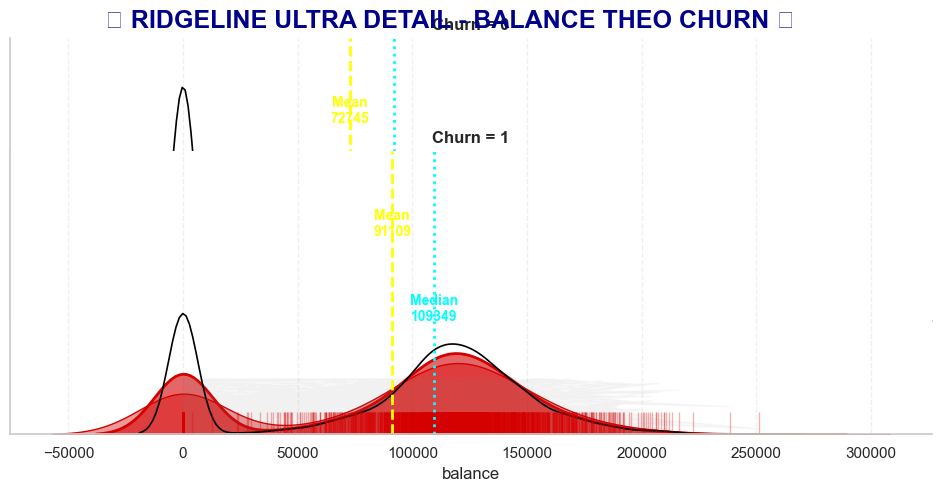

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 1. STYLE NÂNG CAO
# ==============================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,8)

# ==============================
# 2. ĐỌC DỮ LIỆU
# ==============================
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

if 'Exited' in df.columns:
    df.rename(columns={'Exited': 'churn'}, inplace=True)

df = df.dropna(subset=['balance','churn'])

# ==============================
# 3. RIDGELINE MAX DETAIL
# ==============================
g = sns.FacetGrid(
    df,
    row="churn",
    hue="churn",
    aspect=4,
    height=2.5,
    palette={0:"#00C853", 1:"#D50000"}
)

# KDE lớp 1 (rộng - nền)
g.map(
    sns.kdeplot,
    "balance",
    fill=True,
    alpha=0.4,
    bw_adjust=1.5,
    linewidth=1
)

# KDE lớp 2 (chuẩn)
g.map(
    sns.kdeplot,
    "balance",
    fill=True,
    alpha=0.6,
    bw_adjust=1,
    linewidth=2
)

# KDE lớp 3 (chi tiết cao)
g.map(
    sns.kdeplot,
    "balance",
    fill=False,
    color="black",
    bw_adjust=0.5,
    linewidth=1.2
)

# ==============================
# 4. RUGPLOT (tick nhỏ dưới đáy)
# ==============================
g.map(
    sns.rugplot,
    "balance",
    height=0.08,
    alpha=0.3
)

# ==============================
# 5. MEAN + MEDIAN + SHADOW
# ==============================
for ax, churn_value in zip(g.axes.flat, sorted(df['churn'].unique())):
    
    data = df[df['churn'] == churn_value]['balance']
    
    mean = data.mean()
    median = data.median()
    
    # Mean
    ax.axvline(mean, color='yellow', linestyle='--', linewidth=2)
    ax.text(mean, ax.get_ylim()[1]*0.7,
            f'Mean\n{mean:.0f}',
            color='yellow',
            ha='center',
            fontsize=10,
            weight='bold')
    
    # Median
    ax.axvline(median, color='cyan', linestyle=':', linewidth=2)
    ax.text(median, ax.get_ylim()[1]*0.4,
            f'Median\n{median:.0f}',
            color='cyan',
            ha='center',
            fontsize=10,
            weight='bold')

    # Shadow nền (tạo chiều sâu)
    ax.fill_between(
        data,
        0,
        np.random.uniform(0, ax.get_ylim()[1]*0.2, size=len(data)),
        color='gray',
        alpha=0.05
    )

# ==============================
# 6. TRANG TRÍ
# ==============================
g.fig.subplots_adjust(hspace=-0.6)

g.set_titles("Churn = {row_name}", fontsize=14, weight='bold')
g.set(yticks=[], ylabel="")

# Grid + glow effect
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)

# Tiêu đề lớn
g.fig.suptitle(
    "🔥 RIDGELINE ULTRA DETAIL - BALANCE THEO CHURN 🔥",
    fontsize=18,
    weight='bold',
    color='darkblue'
)

plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_6880\1548326788.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 47.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 20.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\PC\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\PC\AppData\Local\Program

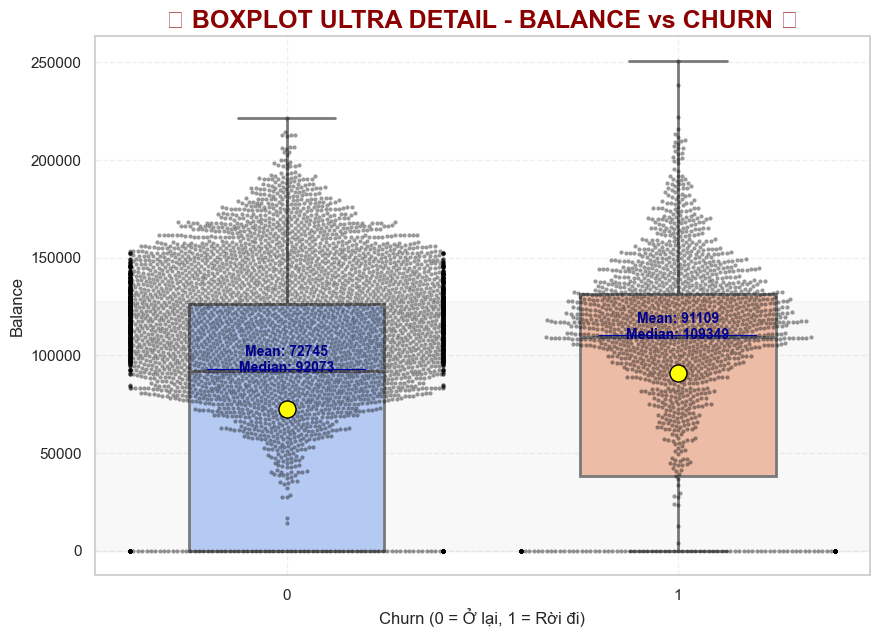

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 1. STYLE
# ==============================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,7))

# ==============================
# 2. ĐỌC DỮ LIỆU
# ==============================
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

if 'Exited' in df.columns:
    df.rename(columns={'Exited': 'churn'}, inplace=True)

df = df.dropna(subset=['balance','churn'])

# ==============================
# 3. PALETTE ĐẸP
# ==============================
palette = sns.color_palette("coolwarm", 2)

# ==============================
# 4. BOXPLOT CHÍNH
# ==============================
ax = sns.boxplot(
    x='churn',
    y='balance',
    data=df,
    palette=palette,
    width=0.5,
    linewidth=2,
    fliersize=4
)

# ==============================
# 5. SWARM (SIÊU CHI TIẾT)
# ==============================
sns.swarmplot(
    x='churn',
    y='balance',
    data=df,
    color='black',
    size=3,
    alpha=0.4
)

# ==============================
# 6. MEAN + MEDIAN + TEXT
# ==============================
for i in [0,1]:
    data = df[df['churn']==i]['balance']
    
    mean = data.mean()
    median = data.median()
    std = data.std()
    
    # Mean
    plt.scatter(i, mean, color='yellow', s=150, edgecolor='black', zorder=5)
    
    # Median line
    plt.plot([i-0.2, i+0.2], [median, median], color='blue', linewidth=3)
    
    # Text annotation
    plt.text(i, mean + std*0.3,
             f"Mean: {mean:.0f}\nMedian: {median:.0f}",
             ha='center',
             fontsize=10,
             color='darkblue',
             weight='bold')

# ==============================
# 7. GRID + TRANG TRÍ
# ==============================
plt.title("🔥 BOXPLOT ULTRA DETAIL - BALANCE vs CHURN 🔥",
          fontsize=18,
          weight='bold',
          color='darkred')

plt.xlabel("Churn (0 = Ở lại, 1 = Rời đi)", fontsize=12)
plt.ylabel("Balance", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

# Highlight vùng giữa
plt.axhspan(df['balance'].quantile(0.25),
            df['balance'].quantile(0.75),
            color='gray',
            alpha=0.05)

plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_6880\734120978.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\PC\AppData\Local\Temp\ipykernel_6880\734120978.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


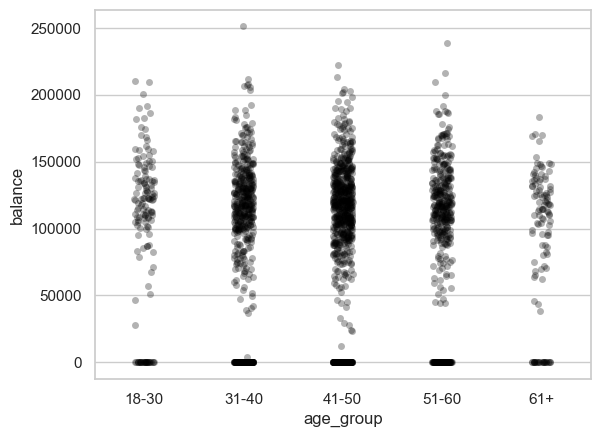

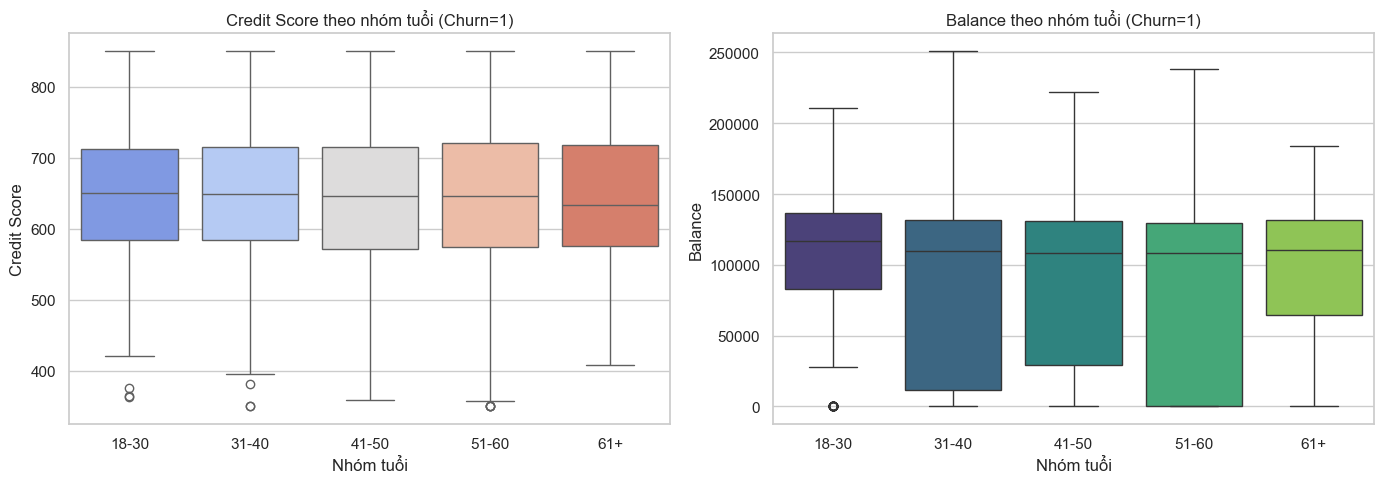

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 1. ĐỌC DỮ LIỆU
# ==============================
df = pd.read_csv('Bank-Customer-Churn-Prediction (1).csv')

if 'Exited' in df.columns:
    df.rename(columns={'Exited': 'churn'}, inplace=True)

# ==============================
# 2. LỌC churn = 1
# ==============================
df_churn = df[df['churn'] == 1].copy()

# ==============================
# 3. CHIA NHÓM TUỔI KHÔNG THẬP PHÂN
# ==============================
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-30', '31-40', '41-50', '51-60', '61+']

df_churn['age_group'] = pd.cut(
    df_churn['age'],
    bins=bins,
    labels=labels
)

# ==============================
# 4. VẼ BIỂU ĐỒ
# ==============================
sns.stripplot(x='age_group', y='balance', data=df_churn,
              color='black', alpha=0.3)
plt.figure(figsize=(14,5))

# Credit score
plt.subplot(1,2,1)
sns.boxplot(
    x='age_group',
    y='credit_score',
    data=df_churn,
    palette='coolwarm'
)
plt.title('Credit Score theo nhóm tuổi (Churn=1)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Credit Score')

# Balance
plt.subplot(1,2,2)
sns.boxplot(
    x='age_group',
    y='balance',
    data=df_churn,
    palette='viridis'
)
plt.title('Balance theo nhóm tuổi (Churn=1)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Balance')

plt.tight_layout()
plt.show()